In [1]:
from pathlib import Path
import sys
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_utils import load_mie_data
from src.peak_utils import build_peak_dataframe, build_combo_lookup, ErrorWeights
from src.env import MieEnv
from src.train import TrainConfig, train_dqn
from src.evaluate import query, brute_force_search
from src.plotting import plot_material_curves, plot_peak_summary, plot_training_curves

DATA_PATH = ROOT / "data" / "processed" / "mie_materials_v1.npz"
OUT_DIR = ROOT / "outputs" / "poster_v4"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "models"
for d in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Root:", ROOT)
print("Device:", device)
print("Outputs:", OUT_DIR)

Root: c:\Users\FURKAN\nanophotonics-rl
Device: cuda
Outputs: c:\Users\FURKAN\nanophotonics-rl\outputs\poster_v4


In [2]:
data = load_mie_data(DATA_PATH)

dataset_summary = pd.DataFrame({
    "quantity": [
        "materials",
        "simulated particles",
        "wavelength points",
        "wavelength min (nm)",
        "wavelength max (nm)",
        "radius min (nm)",
        "radius max (nm)",
    ],
    "value": [
        ", ".join(sorted(map(str, np.unique(data.material_id)))),
        len(data.radius_nm),
        len(data.wavelengths_nm),
        float(data.wavelengths_nm.min()),
        float(data.wavelengths_nm.max()),
        float(data.radius_nm.min()),
        float(data.radius_nm.max()),
    ],
})
dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)
dataset_summary

Loaded: c:\Users\FURKAN\nanophotonics-rl\data\processed\mie_materials_v1.npz
Wavelengths : (61,)
Combos      : (700,)
Radii       : (700,)
sigma_sca   : (700, 61)
sigma_abs   : (700, 61)


,quantity,value
0,materials,"Ag, Al, Au, Cu, GaAs, Ge, Si"
1,simulated particles,700
2,wavelength points,61
3,wavelength min (nm),300.0
4,wavelength max (nm),900.0
5,radius min (nm),50.285656
6,radius max (nm),999.526285


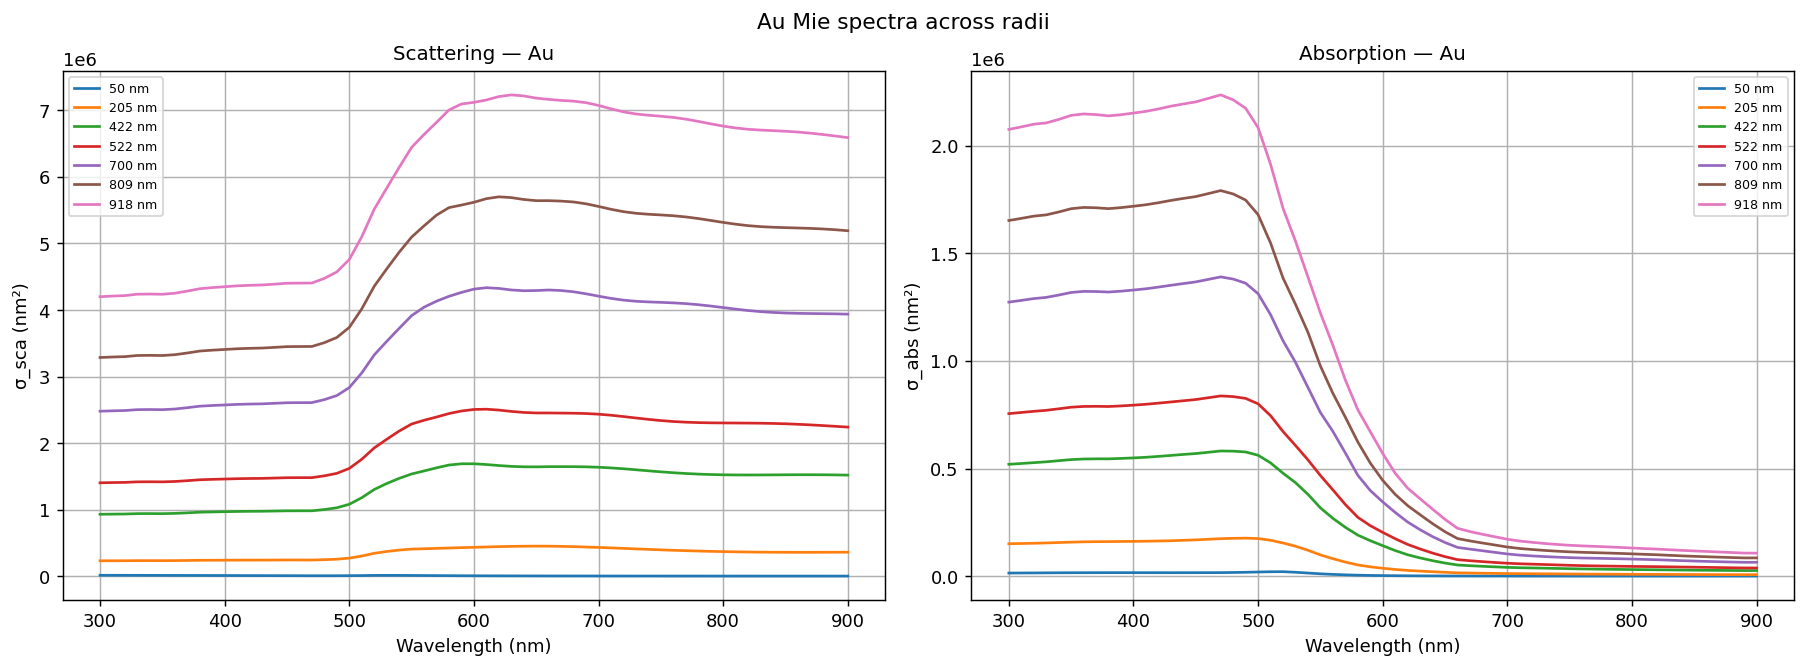

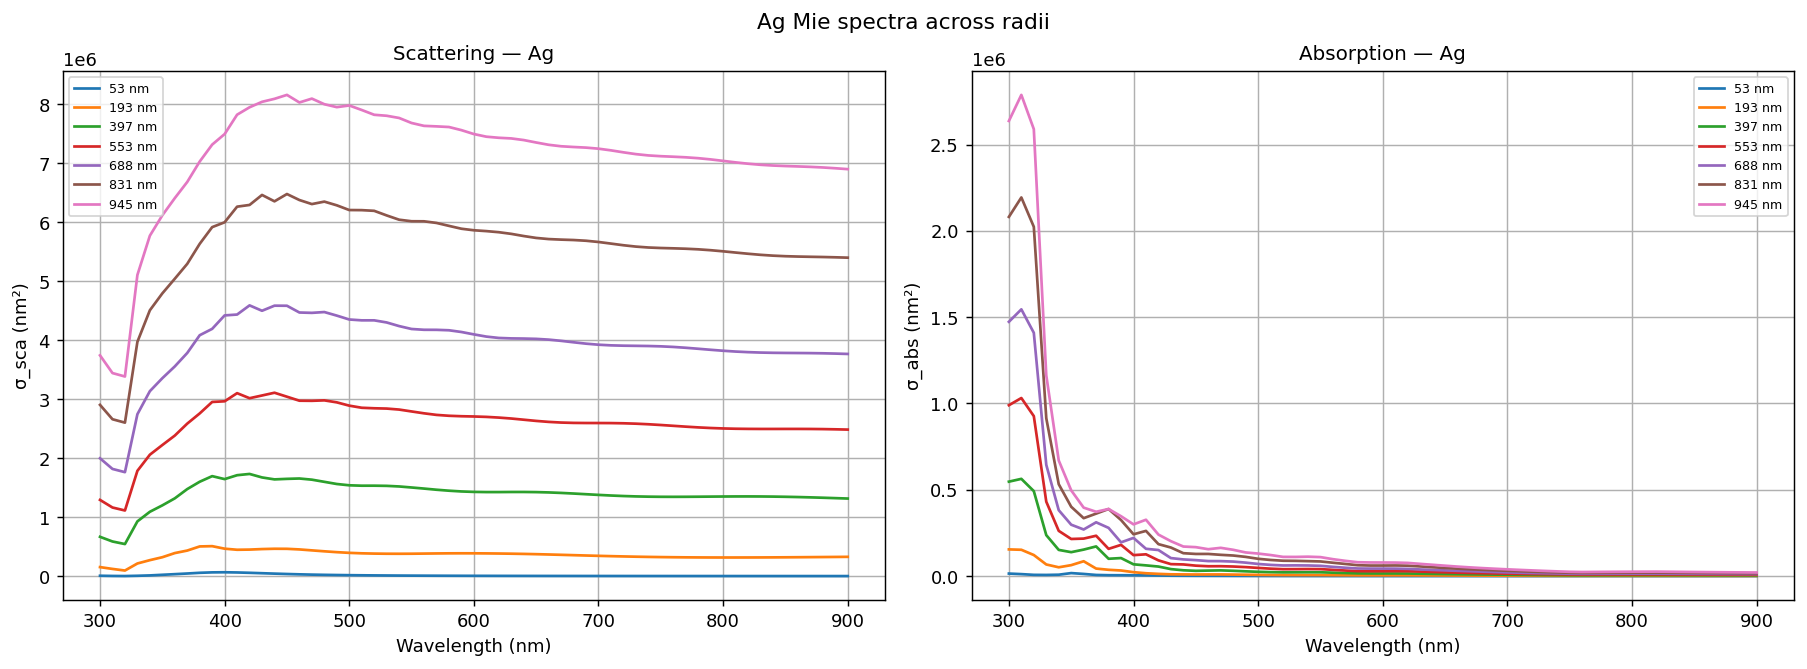

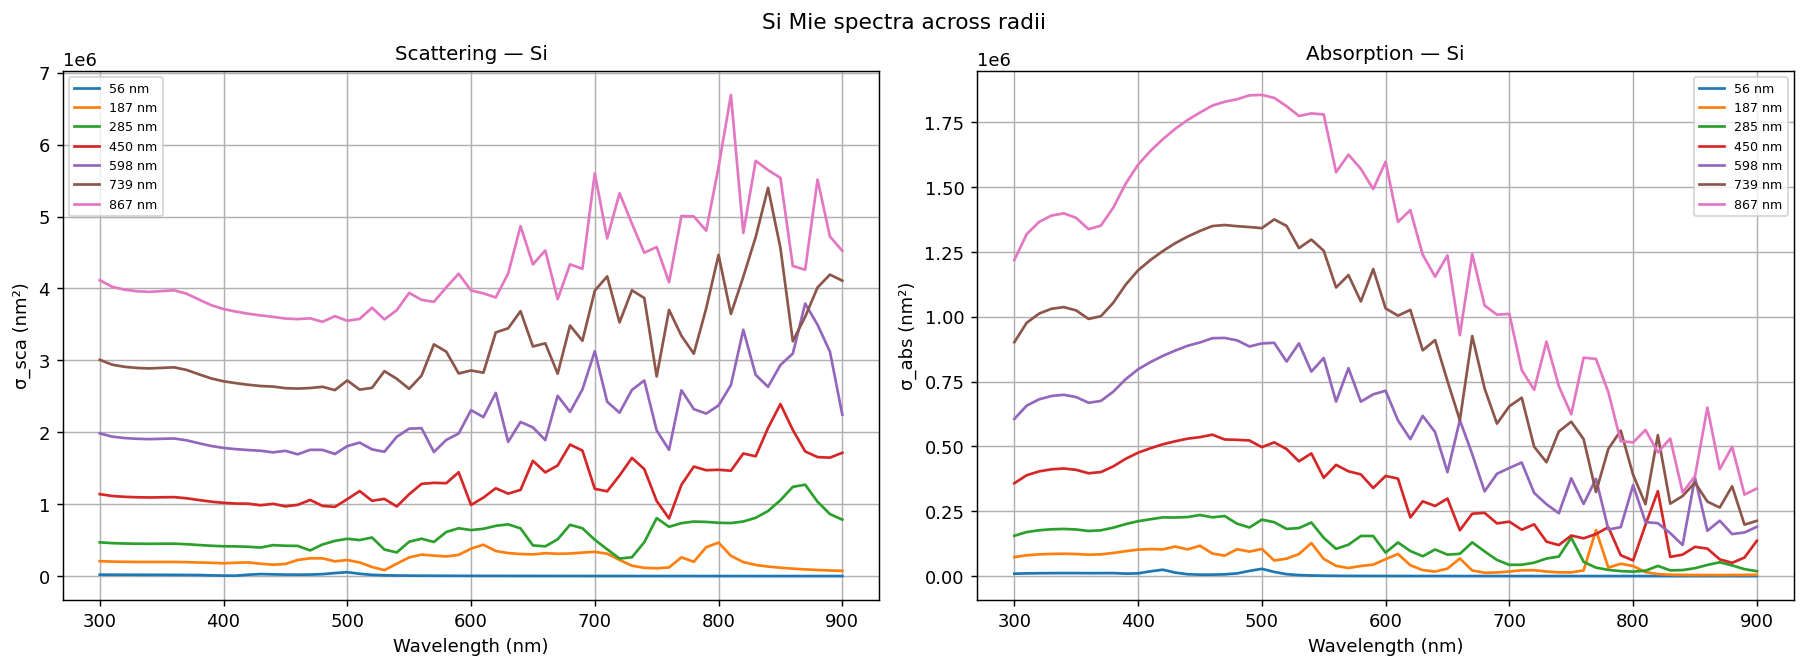

In [3]:
for material in ["Au", "Ag", "Si"]:
    fig, _ = plot_material_curves(data, material_name=material, step=15)
    fig.suptitle(f"{material} Mie spectra across radii", y=1.02)
    fig.savefig(FIG_DIR / f"{material.lower()}_spectra.png", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{material.lower()}_spectra.svg", bbox_inches="tight")
    plt.show()

Mode          : PEAK_MODE=1 (scattering-anchored)
Total peaks   : 979
Unique combos : 700
Lookup source : global-only (700 rows)
combo_lookup  : 700 rows | materials: 7


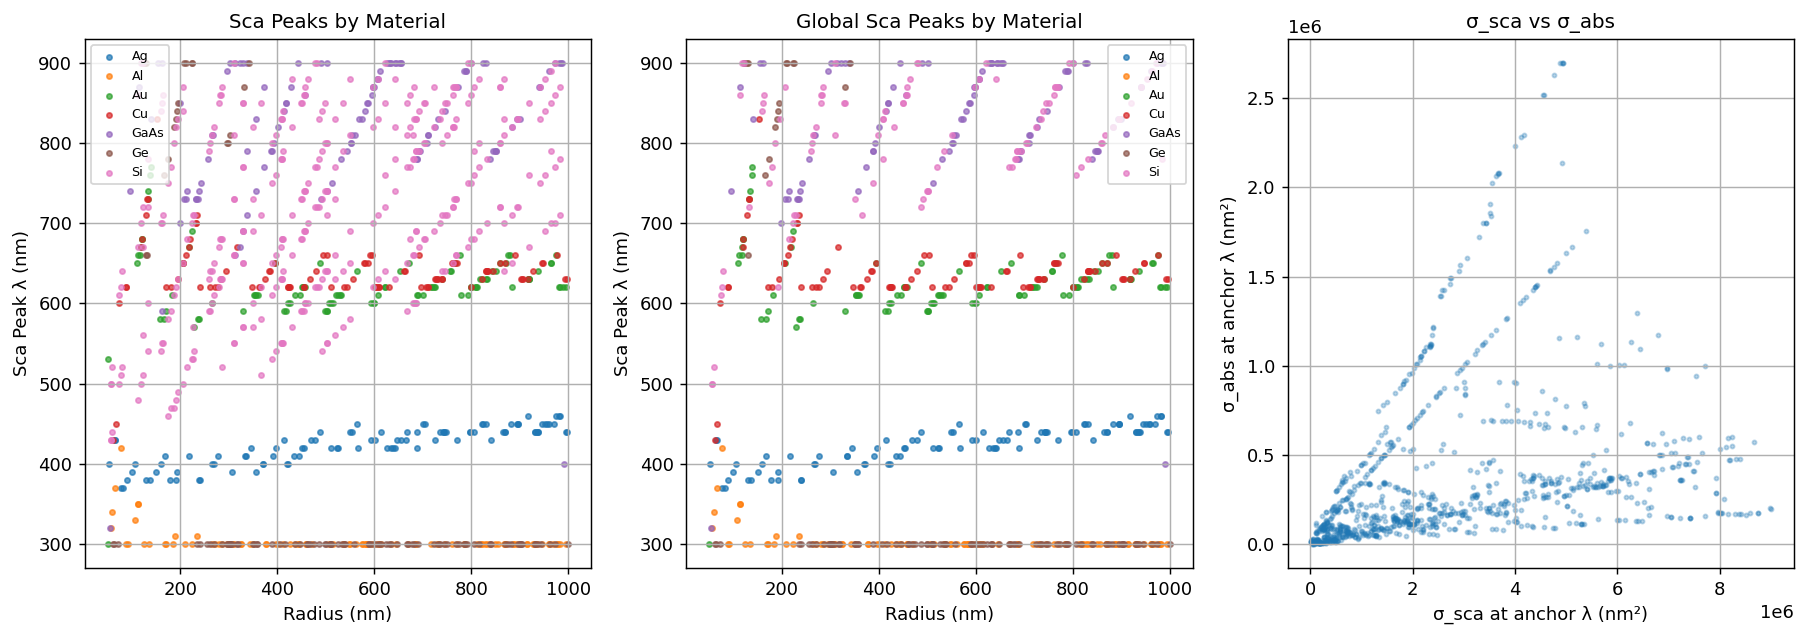

,material,radius_nm,peak_nm,sca_sigma_nm2,abs_sigma_nm2,is_global
0,Ag,52.601575,400.0,65194.399642,4601.090353,True
1,Ag,63.970990,430.0,77323.509818,2393.456113,True
2,Ag,65.701254,430.0,79337.378220,2340.288625,True
3,Ag,76.903688,370.0,108203.256099,23482.641107,True
4,Ag,81.906297,370.0,124368.915516,22739.944170,True


In [4]:
PEAK_MODE = 1
GLOBAL_ONLY = 1
PROMINENCE_FRAC = 0.14
weights = ErrorWeights(peak_wl=0.80, sca_sig=0.10, abs_sig=0.10)

peak_df = build_peak_dataframe(
    data,
    peak_mode=PEAK_MODE,
    prominence_frac=PROMINENCE_FRAC,
    verbose=True,
)
combo_lookup, scales = build_combo_lookup(
    peak_df,
    global_only=GLOBAL_ONLY,
    verbose=True,
)

peak_df.to_csv(TABLE_DIR / "peak_dataframe.csv", index=False)
combo_lookup.to_csv(TABLE_DIR / "combo_lookup.csv", index=False)

fig, _ = plot_peak_summary(peak_df, peak_mode=PEAK_MODE)
fig.savefig(FIG_DIR / "peak_summary.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "peak_summary.svg", bbox_inches="tight")
plt.show()

combo_lookup.head()

In [5]:
env = MieEnv(
    combo_lookup=combo_lookup,
    peak_mode=PEAK_MODE,
    global_only=GLOBAL_ONLY,
    scales=scales,
    weights=weights,
)

state = env.reset()
print("State dimension:", state.shape)
print("Number of actions:", env.N_ACTIONS)
print("Example transition info:")
env.step(1)[3]

State dimension: (9,)
Number of actions: 5
Example transition info:


{'material': 'Ge',
 'radius_nm': 223.57664477916404,
 'peak_wl': 900.0,
 'sca_sig': 313487.36925359303,
 'abs_sig': 179582.09486145477,
 'is_global': True,
 'target_wl': 300.0,
 'target_sca': 3024710.8536250913,
 'target_abs': 186507.8985540486,
 'wl_err': 600.0,
 'sca_sig_err': 2711223.484371498,
 'abs_sig_err': 6925.803692593821,
 'combined_error': 0.8303784268694812,
 'steps': 1}

In [6]:
algorithm_map = pd.DataFrame([
    {
        "lecture_keyword": "Experience replay",
        "project_object": "ReplayBuffer",
        "why_it_matters": "Breaks strong temporal correlation and enables mini-batch SGD.",
    },
    {
        "lecture_keyword": "Target network",
        "project_object": "target_net",
        "why_it_matters": "Keeps the Bellman target from moving too quickly.",
    },
    {
        "lecture_keyword": "Double DQN",
        "project_object": "online action selection + target evaluation",
        "why_it_matters": "Reduces overestimation from max over noisy Q-values.",
    },
    {
        "lecture_keyword": "Dueling DQN",
        "project_object": "value_stream + adv_stream",
        "why_it_matters": "Separates state quality from action-specific advantage.",
    },
    {
        "lecture_keyword": "Exploration vs exploitation",
        "project_object": "epsilon-greedy policy",
        "why_it_matters": "Explores material/radius moves before exploiting the learned policy.",
    },
])
algorithm_map.to_csv(TABLE_DIR / "lecture6_algorithm_map.csv", index=False)
algorithm_map

,lecture_keyword,project_object,why_it_matters
0,Experience replay,ReplayBuffer,Breaks strong temporal correlation and enables...
1,Target network,target_net,Keeps the Bellman target from moving too quickly.
2,Double DQN,online action selection + target evaluation,Reduces overestimation from max over noisy Q-v...
3,Dueling DQN,value_stream + adv_stream,Separates state quality from action-specific a...
4,Exploration vs exploitation,epsilon-greedy policy,Explores material/radius moves before exploiti...


Device: cuda
Ep  100 | eps=0.670 | avg_reward=   0.16 | avg_combined_error=0.3354
Ep  200 | eps=0.449 | avg_reward=   0.92 | avg_combined_error=0.3250
Ep  300 | eps=0.300 | avg_reward=   2.13 | avg_combined_error=0.1616
Ep  400 | eps=0.201 | avg_reward=   2.97 | avg_combined_error=0.1776
Ep  500 | eps=0.135 | avg_reward=   2.58 | avg_combined_error=0.1542
Ep  600 | eps=0.090 | avg_reward=   3.29 | avg_combined_error=0.1215
Ep  700 | eps=0.060 | avg_reward=   2.54 | avg_combined_error=0.1332
Ep  800 | eps=0.050 | avg_reward=   3.16 | avg_combined_error=0.1248
Ep  900 | eps=0.050 | avg_reward=   3.71 | avg_combined_error=0.1161
Ep 1000 | eps=0.050 | avg_reward=   3.82 | avg_combined_error=0.1058
Ep 1100 | eps=0.050 | avg_reward=   3.83 | avg_combined_error=0.1022
Ep 1200 | eps=0.050 | avg_reward=   3.92 | avg_combined_error=0.0621
Training done.


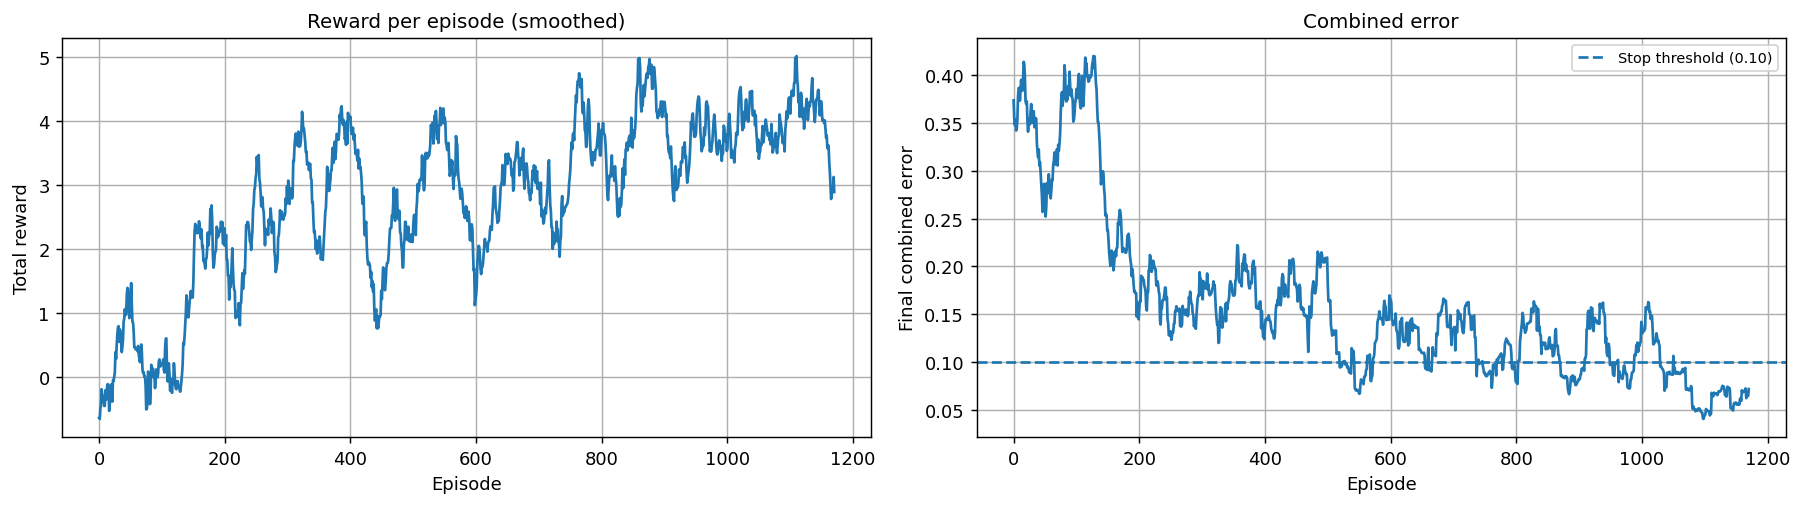

In [7]:
config = TrainConfig(
    episodes=1200,
    batch_size=128,
    gamma=0.99,
    lr=1e-4,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.996,
    target_update=400,
    hidden=256,
    buffer_cap=50_000,
    min_buffer=1_000,
    print_every=100,
)

online_net, history = train_dqn(env, config=config, device=device)

torch.save(
    {
        "model_state_dict": online_net.state_dict(),
        "config": config.__dict__,
        "weights": weights.__dict__,
        "scales": scales.__dict__,
        "seed": SEED,
    },
    MODEL_DIR / "dqn_mode_select_v4.pt",
)

pd.DataFrame({
    "episode": np.arange(1, len(history["episode_rewards"]) + 1),
    "reward": history["episode_rewards"],
    "combined_error": history["episode_errors"],
}).to_csv(TABLE_DIR / "training_history.csv", index=False)

pd.DataFrame({"loss": history["losses"]}).to_csv(TABLE_DIR / "training_losses.csv", index=False)

fig, _ = plot_training_curves(history, stop_threshold=MieEnv.STOP_THRESHOLD, smooth_window=30)
fig.savefig(FIG_DIR / "training_curves.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "training_curves.svg", bbox_inches="tight")
plt.show()

In [8]:
targets = (
    combo_lookup
    .groupby("material", group_keys=False)
    .sample(n=min(2, combo_lookup.groupby("material").size().min()), random_state=SEED)
    .sample(n=10, random_state=SEED)
    .reset_index(drop=True)
)

targets = targets.rename(columns={
    "peak_nm": "target_wl",
    "sca_sigma_nm2": "target_sca",
    "abs_sigma_nm2": "target_abs",
})
targets["target_id"] = [f"T{i+1:02d}" for i in range(len(targets))]
targets[["target_id", "material", "radius_nm", "target_wl", "target_sca", "target_abs"]].to_csv(
    TABLE_DIR / "evaluation_targets.csv",
    index=False,
)
targets[["target_id", "material", "radius_nm", "target_wl", "target_sca", "target_abs"]]

,target_id,material,radius_nm,target_wl,target_sca,target_abs
0,T01,GaAs,530.674002,780.0,1.649415e+06,8.500959e+05
1,T02,Ge,475.465444,300.0,1.263635e+06,4.404747e+05
2,T03,Ag,895.760634,450.0,7.419448e+06,1.478595e+05
3,T04,Si,761.454852,860.0,5.538061e+06,3.242207e+05
4,T05,Au,412.724041,590.0,1.617869e+06,1.602197e+05
5,T06,GaAs,960.488868,890.0,4.755858e+06,2.632756e+06
6,T07,Al,855.876648,300.0,5.674198e+06,3.464416e+05
7,T08,Ag,639.202779,420.0,4.024870e+06,1.261666e+05
8,T09,Si,685.291723,790.0,4.281991e+06,3.539886e+05
9,T10,Au,532.096368,610.0,2.604071e+06,1.781628e+05


In [9]:
all_rl_rows = []
summary_rows = []

for row in targets.itertuples(index=False):
    rl_df = query(
        online_net,
        env,
        target_wl=float(row.target_wl),
        target_sca=float(row.target_sca),
        target_abs=float(row.target_abs),
        n_trials=200,
        device=device,
        verbose=False,
    )
    rl_df.insert(0, "target_id", row.target_id)
    all_rl_rows.append(rl_df)

    bf = brute_force_search(
        combo_lookup,
        target_wl=float(row.target_wl),
        target_sca=float(row.target_sca),
        target_abs=float(row.target_abs),
        scales=scales,
        weights=weights,
        top_k=1,
    ).iloc[0]

    best = rl_df.iloc[0]
    summary_rows.append({
        "target_id": row.target_id,
        "target_material": row.material,
        "target_radius_nm": row.radius_nm,
        "target_wl_nm": row.target_wl,
        "rl_material": best.material,
        "rl_radius_nm": best.radius_nm,
        "rl_peak_wl_nm": best.peak_wl,
        "rl_wl_err_nm": best.wl_err,
        "rl_combined_error": best.combined_error,
        "rl_success_rate_pct": 100 * (rl_df["combined_error"] < MieEnv.STOP_THRESHOLD).mean(),
        "rl_mean_steps": rl_df["steps"].mean(),
        "bf_material": bf.material,
        "bf_radius_nm": bf.radius_nm,
        "bf_peak_wl_nm": bf.peak_nm,
        "bf_wl_err_nm": abs(bf.peak_nm - row.target_wl),
        "bf_combined_error": bf.combined_error,
        "matches_bf_material": best.material == bf.material,
        "radius_abs_diff_vs_bf_nm": abs(best.radius_nm - bf.radius_nm),
    })

rl_trials = pd.concat(all_rl_rows, ignore_index=True)
eval_summary = pd.DataFrame(summary_rows)

rl_trials.to_csv(TABLE_DIR / "rl_query_trials.csv", index=False)
eval_summary.to_csv(TABLE_DIR / "evaluation_summary.csv", index=False)

eval_summary

,target_id,target_material,target_radius_nm,target_wl_nm,rl_material,rl_radius_nm,rl_peak_wl_nm,rl_wl_err_nm,rl_combined_error,rl_success_rate_pct,rl_mean_steps,bf_material,bf_radius_nm,bf_peak_wl_nm,bf_wl_err_nm,bf_combined_error,matches_bf_material,radius_abs_diff_vs_bf_nm
0,T01,GaAs,530.674002,780.0,GaAs,530.674002,780.0,0.0,0.000000,72.0,88.945,GaAs,530.674002,780.0,0.0,0.0,True,0.000000
1,T02,Ge,475.465444,300.0,Ge,460.651716,300.0,0.0,0.001760,87.5,40.550,Ge,475.465444,300.0,0.0,0.0,True,14.813728
2,T03,Ag,895.760634,450.0,Ag,951.496491,450.0,0.0,0.010475,68.5,148.520,Ag,895.760634,450.0,0.0,0.0,True,55.735857
3,T04,Si,761.454852,860.0,Si,761.454852,860.0,0.0,0.000000,58.0,71.655,Si,761.454852,860.0,0.0,0.0,True,0.000000
4,T05,Au,412.724041,590.0,Au,412.724041,590.0,0.0,0.000000,20.0,136.095,Au,412.724041,590.0,0.0,0.0,True,0.000000
5,T06,GaAs,960.488868,890.0,GaAs,612.307644,890.0,0.0,0.084298,21.5,150.000,GaAs,960.488868,890.0,0.0,0.0,True,348.181224
6,T07,Al,855.876648,300.0,Al,537.120787,300.0,0.0,0.044542,43.5,99.680,Al,855.876648,300.0,0.0,0.0,True,318.755861
7,T08,Ag,639.202779,420.0,Ag,642.027787,420.0,0.0,0.000273,77.0,138.230,Ag,639.202779,420.0,0.0,0.0,True,2.825008
8,T09,Si,685.291723,790.0,Si,685.291723,790.0,0.0,0.000000,47.0,133.170,Si,685.291723,790.0,0.0,0.0,True,0.000000
9,T10,Au,532.096368,610.0,Au,532.096368,610.0,0.0,0.000000,56.5,117.050,Au,532.096368,610.0,0.0,0.0,True,0.000000


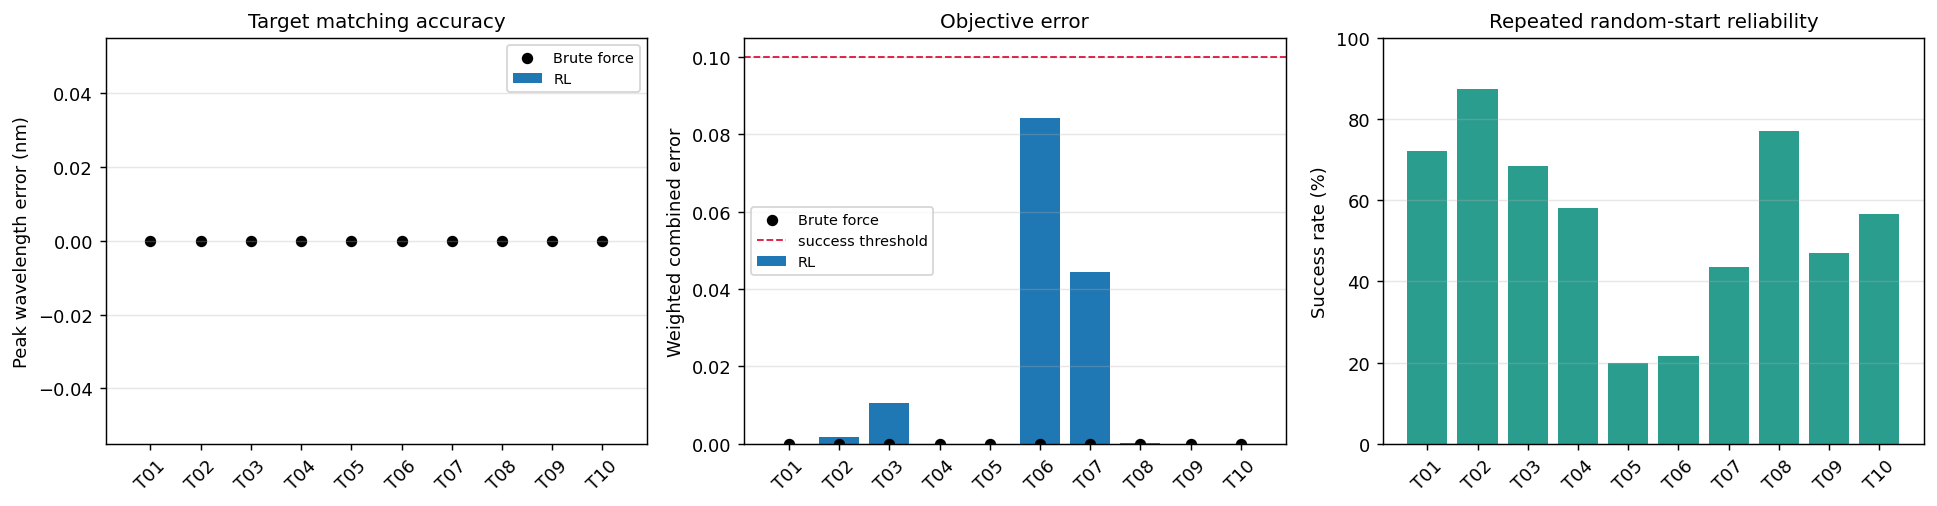

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(eval_summary["target_id"], eval_summary["rl_wl_err_nm"], label="RL")
axes[0].scatter(eval_summary["target_id"], eval_summary["bf_wl_err_nm"], color="black", s=28, label="Brute force")
axes[0].set_ylabel("Peak wavelength error (nm)")
axes[0].set_title("Target matching accuracy")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(eval_summary["target_id"], eval_summary["rl_combined_error"], label="RL")
axes[1].scatter(eval_summary["target_id"], eval_summary["bf_combined_error"], color="black", s=28, label="Brute force")
axes[1].axhline(MieEnv.STOP_THRESHOLD, color="crimson", linestyle="--", linewidth=1, label="success threshold")
axes[1].set_ylabel("Weighted combined error")
axes[1].set_title("Objective error")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(eval_summary["target_id"], eval_summary["rl_success_rate_pct"], color="#2a9d8f")
axes[2].set_ylim(0, 100)
axes[2].set_ylabel("Success rate (%)")
axes[2].set_title("Repeated random-start reliability")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "poster_metrics.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "poster_metrics.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "poster_metrics.pdf", bbox_inches="tight")
plt.show()

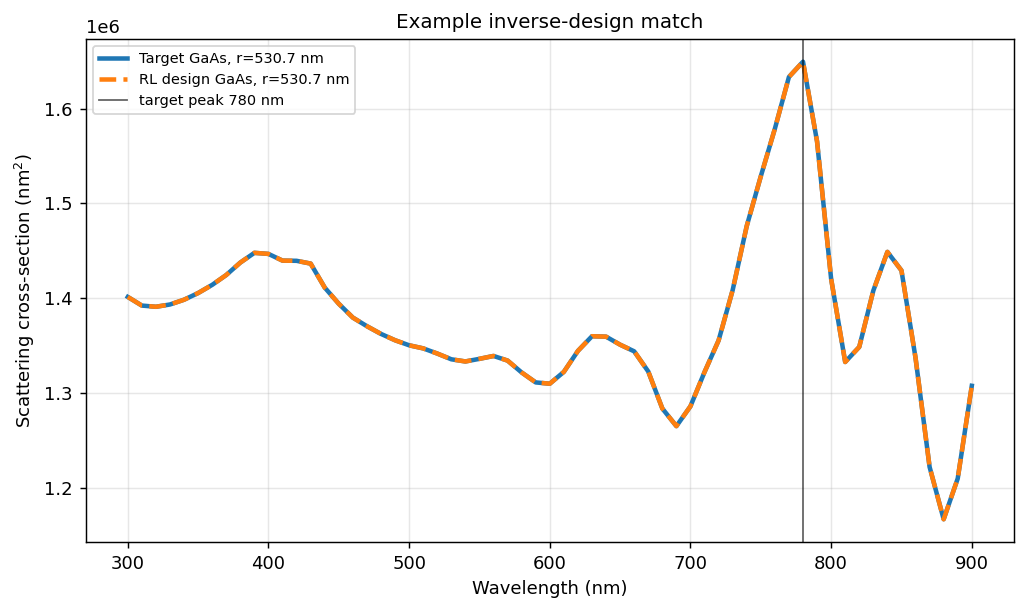

In [11]:
best_target_id = eval_summary.sort_values("rl_combined_error").iloc[0]["target_id"]
best_target = targets[targets["target_id"] == best_target_id].iloc[0]
best_rl = rl_trials[rl_trials["target_id"] == best_target_id].iloc[0]

mask_target = (data.material_id == best_target.material) & np.isclose(data.radius_nm, best_target.radius_nm)
mask_rl = (data.material_id == best_rl.material) & np.isclose(data.radius_nm, best_rl.radius_nm)

fig, ax = plt.subplots(figsize=(8, 4.8))
if mask_target.any():
    i = np.flatnonzero(mask_target)[0]
    ax.plot(data.wavelengths_nm, data.sigma_sca[i], label=f"Target {best_target.material}, r={best_target.radius_nm:.1f} nm", linewidth=2.5)
if mask_rl.any():
    j = np.flatnonzero(mask_rl)[0]
    ax.plot(data.wavelengths_nm, data.sigma_sca[j], "--", label=f"RL design {best_rl.material}, r={best_rl.radius_nm:.1f} nm", linewidth=2.5)

ax.axvline(best_target.target_wl, color="black", linewidth=1, alpha=0.6, label=f"target peak {best_target.target_wl:.0f} nm")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Scattering cross-section (nm$^2$)")
ax.set_title("Example inverse-design match")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "best_match_spectrum.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "best_match_spectrum.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "best_match_spectrum.pdf", bbox_inches="tight")
plt.show()

In [12]:
poster_summary = {
    "n_targets": int(len(eval_summary)),
    "mean_rl_wavelength_error_nm": float(eval_summary["rl_wl_err_nm"].mean()),
    "median_rl_wavelength_error_nm": float(eval_summary["rl_wl_err_nm"].median()),
    "mean_rl_combined_error": float(eval_summary["rl_combined_error"].mean()),
    "mean_success_rate_pct": float(eval_summary["rl_success_rate_pct"].mean()),
    "bf_material_match_rate_pct": float(100 * eval_summary["matches_bf_material"].mean()),
    "output_directory": str(OUT_DIR),
}

with open(OUT_DIR / "poster_summary.json", "w", encoding="utf-8") as f:
    json.dump(poster_summary, f, indent=2)

poster_summary

{'n_targets': 10,
 'mean_rl_wavelength_error_nm': 0.0,
 'median_rl_wavelength_error_nm': 0.0,
 'mean_rl_combined_error': 0.014134708685249677,
 'mean_success_rate_pct': 55.15,
 'bf_material_match_rate_pct': 100.0,
 'output_directory': 'c:\\Users\\FURKAN\\nanophotonics-rl\\outputs\\poster_v4'}

In [13]:
noise_levels = [0.0, 5.0, 10.0, 20.0]  # wavelength noise standard deviation in nm
robust_rows = []

rng = np.random.default_rng(SEED)
base_targets = targets.head(5).copy()

for noise_nm in noise_levels:
    for row in base_targets.itertuples(index=False):
        noisy_wl = float(row.target_wl + rng.normal(0.0, noise_nm))
        noisy_sca = float(row.target_sca * (1.0 + rng.normal(0.0, noise_nm / 200.0)))
        noisy_abs = float(row.target_abs * (1.0 + rng.normal(0.0, noise_nm / 200.0)))

        rl_df = query(
            online_net,
            env,
            target_wl=noisy_wl,
            target_sca=noisy_sca,
            target_abs=noisy_abs,
            n_trials=80,
            device=device,
            verbose=False,
        )

        best = rl_df.iloc[0]
        bf = brute_force_search(
            combo_lookup,
            target_wl=noisy_wl,
            target_sca=noisy_sca,
            target_abs=noisy_abs,
            scales=scales,
            weights=weights,
            top_k=1,
        ).iloc[0]

        robust_rows.append({
            "noise_nm_std": noise_nm,
            "target_id": row.target_id,
            "noisy_target_wl_nm": noisy_wl,
            "rl_material": best.material,
            "rl_radius_nm": best.radius_nm,
            "rl_wl_err_nm": best.wl_err,
            "rl_combined_error": best.combined_error,
            "rl_success_rate_pct": 100 * (rl_df["combined_error"] < MieEnv.STOP_THRESHOLD).mean(),
            "bf_material": bf.material,
            "bf_radius_nm": bf.radius_nm,
            "bf_combined_error": bf.combined_error,
        })

robustness_df = pd.DataFrame(robust_rows)
robustness_df.to_csv(TABLE_DIR / "robustness_target_noise.csv", index=False)

robustness_summary = (
    robustness_df
    .groupby("noise_nm_std", as_index=False)
    .agg(
        mean_rl_wl_err_nm=("rl_wl_err_nm", "mean"),
        mean_rl_combined_error=("rl_combined_error", "mean"),
        mean_success_rate_pct=("rl_success_rate_pct", "mean"),
        mean_bf_combined_error=("bf_combined_error", "mean"),
    )
)
robustness_summary.to_csv(TABLE_DIR / "robustness_summary.csv", index=False)
robustness_summary

,noise_nm_std,mean_rl_wl_err_nm,mean_rl_combined_error,mean_success_rate_pct,mean_bf_combined_error
0,0.0,2.000000,0.011332,63.25,0.000000
1,5.0,5.212444,0.010572,51.50,0.005185
2,10.0,6.168569,0.011616,57.75,0.006973
3,20.0,8.504797,0.016004,61.00,0.010169


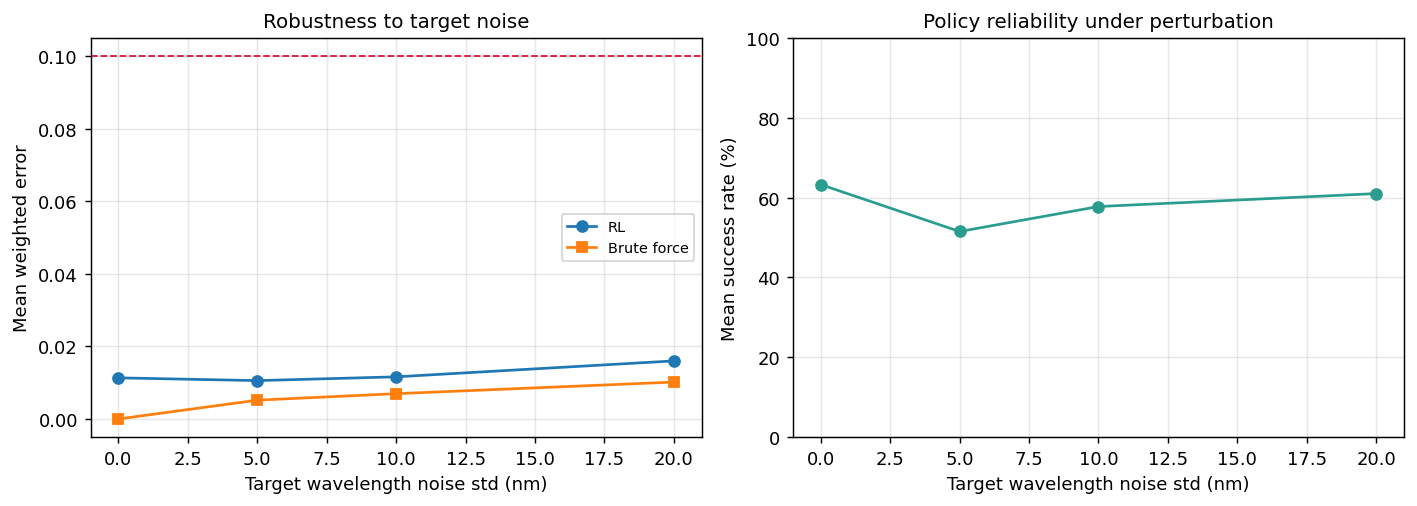

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    robustness_summary["noise_nm_std"],
    robustness_summary["mean_rl_combined_error"],
    marker="o",
    label="RL",
)
axes[0].plot(
    robustness_summary["noise_nm_std"],
    robustness_summary["mean_bf_combined_error"],
    marker="s",
    label="Brute force",
)
axes[0].axhline(MieEnv.STOP_THRESHOLD, color="crimson", linestyle="--", linewidth=1)
axes[0].set_xlabel("Target wavelength noise std (nm)")
axes[0].set_ylabel("Mean weighted error")
axes[0].set_title("Robustness to target noise")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    robustness_summary["noise_nm_std"],
    robustness_summary["mean_success_rate_pct"],
    marker="o",
    color="#2a9d8f",
)
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("Target wavelength noise std (nm)")
axes[1].set_ylabel("Mean success rate (%)")
axes[1].set_title("Policy reliability under perturbation")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "robustness_target_noise.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "robustness_target_noise.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "robustness_target_noise.pdf", bbox_inches="tight")
plt.show()